<a href="https://colab.research.google.com/github/rylan-berry/DataScienceExercises2025-2026/blob/main/RylaBerrU7proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pulse Rate Analysis 🏃



###Imports and Data Install

In [1]:
!pip install bambi
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import arviz as az
import graphviz as gv
import seaborn as sns
import bambi as bmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 6.9 MB/s eta 0:00:00


In [2]:
!git clone 'https://github.com/rylan-berry/DataScienceExercises2025-2026.git'

Cloning into 'DataScienceExercises2025-2026'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 119 (delta 51), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 9.65 MiB | 10.58 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [3]:
#Code created by Gemini to extract the data
import json
import pandas as pd
import os
import zipfile

# Existing unzip function
def unzip_mwx(mwx_filepath, extract_dir="./mwx_extracted"):
    """
    Unzips the .mwx file into a specified directory.
    """
    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir)

    with zipfile.ZipFile(mwx_filepath, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted files to {extract_dir}")
    return extract_dir

file = unzip_mwx('DataScienceExercises2025-2026/PulseRates.MWX')

# Load the sheet.json file into a pandas DataFrame
json_filepath = os.path.join(file, 'sheets', '0', 'sheet.json')

try:
    with open(json_filepath, 'r') as f:
        json_data_raw = json.load(f)

    if 'Data' in json_data_raw and 'Columns' in json_data_raw['Data']:
        columns_list = json_data_raw['Data']['Columns']
        dataframe_data = {}
        print(f"Found {len(columns_list)} potential columns.")
        for i, col_def in enumerate(columns_list):
            # Debugging prints:
            print(f"\n--- Processing column definition {i} ---")
            # print(f"Full col_def: {col_def}") # This can be very verbose, uncomment if needed

            # Correctly access nested 'Name'
            col_name = col_def.get('WorksheetVarBody', {}).get('Name')

            # Access VarData dictionary
            var_data = col_def.get('WorksheetVarBody', {}).get('VarData', {})

            # Access VarDataBody and try to get 'NumericData' or 'TextData'
            var_data_body = var_data.get('VarDataBody', {})
            col_values = None
            if var_data_body.get('HasNumericData'):
                col_values = var_data_body.get('NumericData')
            elif var_data_body.get('HasTextData'):
                col_values = var_data_body.get('TextData')

            print(f"Extracted col_name: {col_name}")
            print(f"Contents of VarData (if available): {var_data}") # Added for debugging
            print(f"Keys in VarData: {list(var_data.keys())}") # Added for debugging
            print(f"Extracted col_values (first 5 elements): {col_values[:5] if col_values else 'None/Empty'}")

            if col_name and col_values is not None:
                dataframe_data[col_name] = col_values
                print(f"Successfully added column '{col_name}' to dataframe_data.")
            else:
                print(f"Skipping column due to missing name or values: Name='{col_name}', Values present={col_values is not None}")

        if dataframe_data:
            # Ensure all lists in dataframe_data have the same length
            # This can happen if some columns have fewer values.
            # A common approach is to pad with None or NaN, or identify min length.
            # For now, let's assume they should be consistent, and if not, this will raise an error.
            # If data is irregular, further investigation into padding or different structuring will be needed.
            df = pd.DataFrame(dataframe_data)
            print("\nData loaded into pandas DataFrame successfully!")
            print(df.head())
        else:
            print("\nNo valid column data found to create a DataFrame after checking nested keys.")
    else:
        print("Expected keys 'Data' or 'Columns' not found in the JSON structure.")
        print(f"Top-level keys in JSON: {json_data_raw.keys()}")

except FileNotFoundError:
    print(f"Error: {json_filepath} not found.")
except Exception as e:
    print(f"An error occurred while loading the JSON into a DataFrame: {e}")

Extracted files to ./mwx_extracted
Found 8 potential columns.

--- Processing column definition 0 ---
Extracted col_name: Pulse1
Contents of VarData (if available): {'ClassId': 439, 'VariableType': 3, 'Data': 1, 'VarDataBody': {'ClassId': 447, 'CellCt': 91, 'ColCt': 1, 'CharCt': 0, 'HasNumericData': True, 'NumericData': [64.0, 58.0, 62.0, 66.0, 64.0, 74.0, 84.0, 68.0, 62.0, 76.0, 90.0, 80.0, 92.0, 68.0, 60.0, 62.0, 66.0, 70.0, 68.0, 72.0, 70.0, 74.0, 66.0, 70.0, 96.0, 62.0, 78.0, 82.0, 100.0, 68.0, 96.0, 78.0, 88.0, 62.0, 80.0, 62.0, 60.0, 72.0, 62.0, 76.0, 68.0, 54.0, 74.0, 74.0, 68.0, 72.0, 68.0, 82.0, 64.0, 58.0, 54.0, 70.0, 62.0, 76.0, 88.0, 70.0, 90.0, 78.0, 70.0, 90.0, 92.0, 60.0, 72.0, 68.0, 84.0, 74.0, 68.0, 84.0, 61.0, 64.0, 94.0, 60.0, 72.0, 58.0, 88.0, 66.0, 84.0, 62.0, 66.0, 80.0, 78.0, 68.0, 72.0, 82.0, 76.0, 87.0, 90.0, 78.0, 68.0, 86.0, 76.0], 'HasTextData': False}, 'Locked': False, 'Class_Version': [2]}
Keys in VarData: ['ClassId', 'VariableType', 'Data', 'VarDataBody',

In [4]:
df

,Pulse1,Pulse2,Ran,Smokes,Gender,Height,Weight,Activity
0,64.0,88.0,Yes,No,M,66.00,140.0,Moderate
1,58.0,70.0,Yes,No,M,72.00,145.0,Moderate
2,62.0,76.0,Yes,Yes,M,73.50,160.0,A lot
3,66.0,78.0,Yes,Yes,M,73.00,190.0,Slight
4,64.0,80.0,Yes,No,M,69.00,155.0,Moderate
...,...,...,...,...,...,...,...,...
86,90.0,92.0,No,Yes,F,64.00,125.0,Slight
87,78.0,80.0,No,No,F,68.00,133.0,Slight
88,68.0,68.0,No,No,F,62.00,110.0,Moderate
89,86.0,84.0,No,No,F,67.00,150.0,A lot


##Context


Pulse is a standard indicator of a person's bodily stress, lower means you're body is having a good time, higher means you're body is having some trouble. So, I was wondered how a person's stress (i.e. pulse) changes after exercising given a person's lifestyle choices beyond simple phisological differences like height, weight, and gender. Thankfully, I found this data set that could be analyized to figure it out not only a persons resting pulse (stress), but also their pulse after exercising!

##The Data

In [5]:
df = df.rename(columns={'Pulse1': 'RestPulse', 'Pulse2': 'ActivePulse'})
df

,RestPulse,ActivePulse,Ran,Smokes,Gender,Height,Weight,Activity
0,64.0,88.0,Yes,No,M,66.00,140.0,Moderate
1,58.0,70.0,Yes,No,M,72.00,145.0,Moderate
2,62.0,76.0,Yes,Yes,M,73.50,160.0,A lot
3,66.0,78.0,Yes,Yes,M,73.00,190.0,Slight
4,64.0,80.0,Yes,No,M,69.00,155.0,Moderate
...,...,...,...,...,...,...,...,...
86,90.0,92.0,No,Yes,F,64.00,125.0,Slight
87,78.0,80.0,No,No,F,68.00,133.0,Slight
88,68.0,68.0,No,No,F,62.00,110.0,Moderate
89,86.0,84.0,No,No,F,67.00,150.0,A lot


The data was downloaded from [Minitab](https://support.minitab.com/en-us/datasets/regression-data-sets/pulse-rates-data/) which "provides a library of sample data sets taken from real-life scenarios across many different industries and fields of study". So I'm going to trust this as real data as much as I would with Kaggle data.

Besides that, the data has a few variables:

**Resting Pulse**, which is the standard pulse of the person;

**Ran**, whether the person ran or not;

**'Active' pulse**, the pulse of the person after running (or after not running);

**Smokes**, if they smoke or not;

**Gender**;
**Height**;
**Weight**;

and **Activty**, how active is the person normally (arbitrary values of *Slight*, *Moderate*, and *A lot*).

## Previous Assumptions About The Data

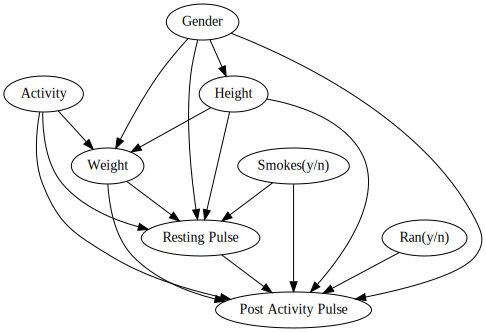

In [ ]:

p_dag = gv.Digraph(name="Pulse DAG")

p_dag.node('H','Height')
p_dag.node('A','Activity')
p_dag.node('W','Weight')
p_dag.node('P','Resting Pulse')
p_dag.node('G','Gender')
p_dag.node('R','Ran(y/n)')
p_dag.node('S','Smokes(y/n)')
p_dag.node('p','Post Activity Pulse')

p_dag.edges(['Pp', 'Sp','SP', 'Wp', 'Hp', 'Ap', 'Gp','HP','WP', 'Rp','HW','AW','GH','GW','GP','AP'])

p_dag


 - Biological differences in gender.
 - Taller means more volume and hence greater weight.
 - Activity (how much a person exercises on average) effects weight.
 - Greater height and weight likely needs a greater pulse to transport blood greater distances.
 - Another assumption is that whether the student ran or not will effect their pulse *(May consider doing a ran only model)* can probably make this a heirarchy.

In [ ]:
#(mostly) Gemini generated code to make encodings for categorical variables.
temp_df = df.copy()

# Convert 'Ran', 'Smokes', 'Gender' to 0s and 1s using one-hot encoding
temp_df['Ran_encoded'] = temp_df['Ran'].apply(lambda x: 1 if x == 'Yes' else 0)
temp_df['Smokes_encoded'] = temp_df['Smokes'].apply(lambda x: 1 if x == 'Yes' else 0)
temp_df['Gender_encoded'] = temp_df['Gender'].apply(lambda x: 1 if x == 'F' else 0) # Assuming M is 0, F is 1

# Map 'Activity' to numerical values
activity_mapping = {'Slight': 0, 'Moderate': 1, 'A lot': 2}
temp_df['Activity_encoded'] = temp_df['Activity'].map(activity_mapping)

# Display the first few rows of the temporary DataFrame with the new columns
#print("First 5 rows with new encodings:")
#print(temp_df[['Ran', 'Ran_encoded', 'Smokes', 'Smokes_encoded', 'Gender', 'Gender_encoded', 'Activity', 'Activity_encoded']].head())

print("\nUnique encoded values:")
print(f"Ran_encoded: {temp_df['Ran_encoded'].unique()}\tRan: {temp_df['Ran'].unique()}")
print(f"Smokes_encoded: {temp_df['Smokes_encoded'].unique()}\tSmokes: {temp_df['Smokes'].unique()}")
print(f"Gender_encoded: {temp_df['Gender_encoded'].unique()}\tGender: {temp_df['Gender'].unique()}")
print(f"Activ_encoded: {temp_df['Activity_encoded'].unique()}\tActivity: {temp_df['Activity'].unique()}")


Unique encoded values:
Ran_encoded: [1 0]	Ran: ['Yes' 'No']
Smokes_encoded: [0 1]	Smokes: ['No' 'Yes']
Gender_encoded: [0 1]	Gender: ['M' 'F']
Activ_encoded: [1 2 0]	Activity: ['Moderate' 'A lot' 'Slight']


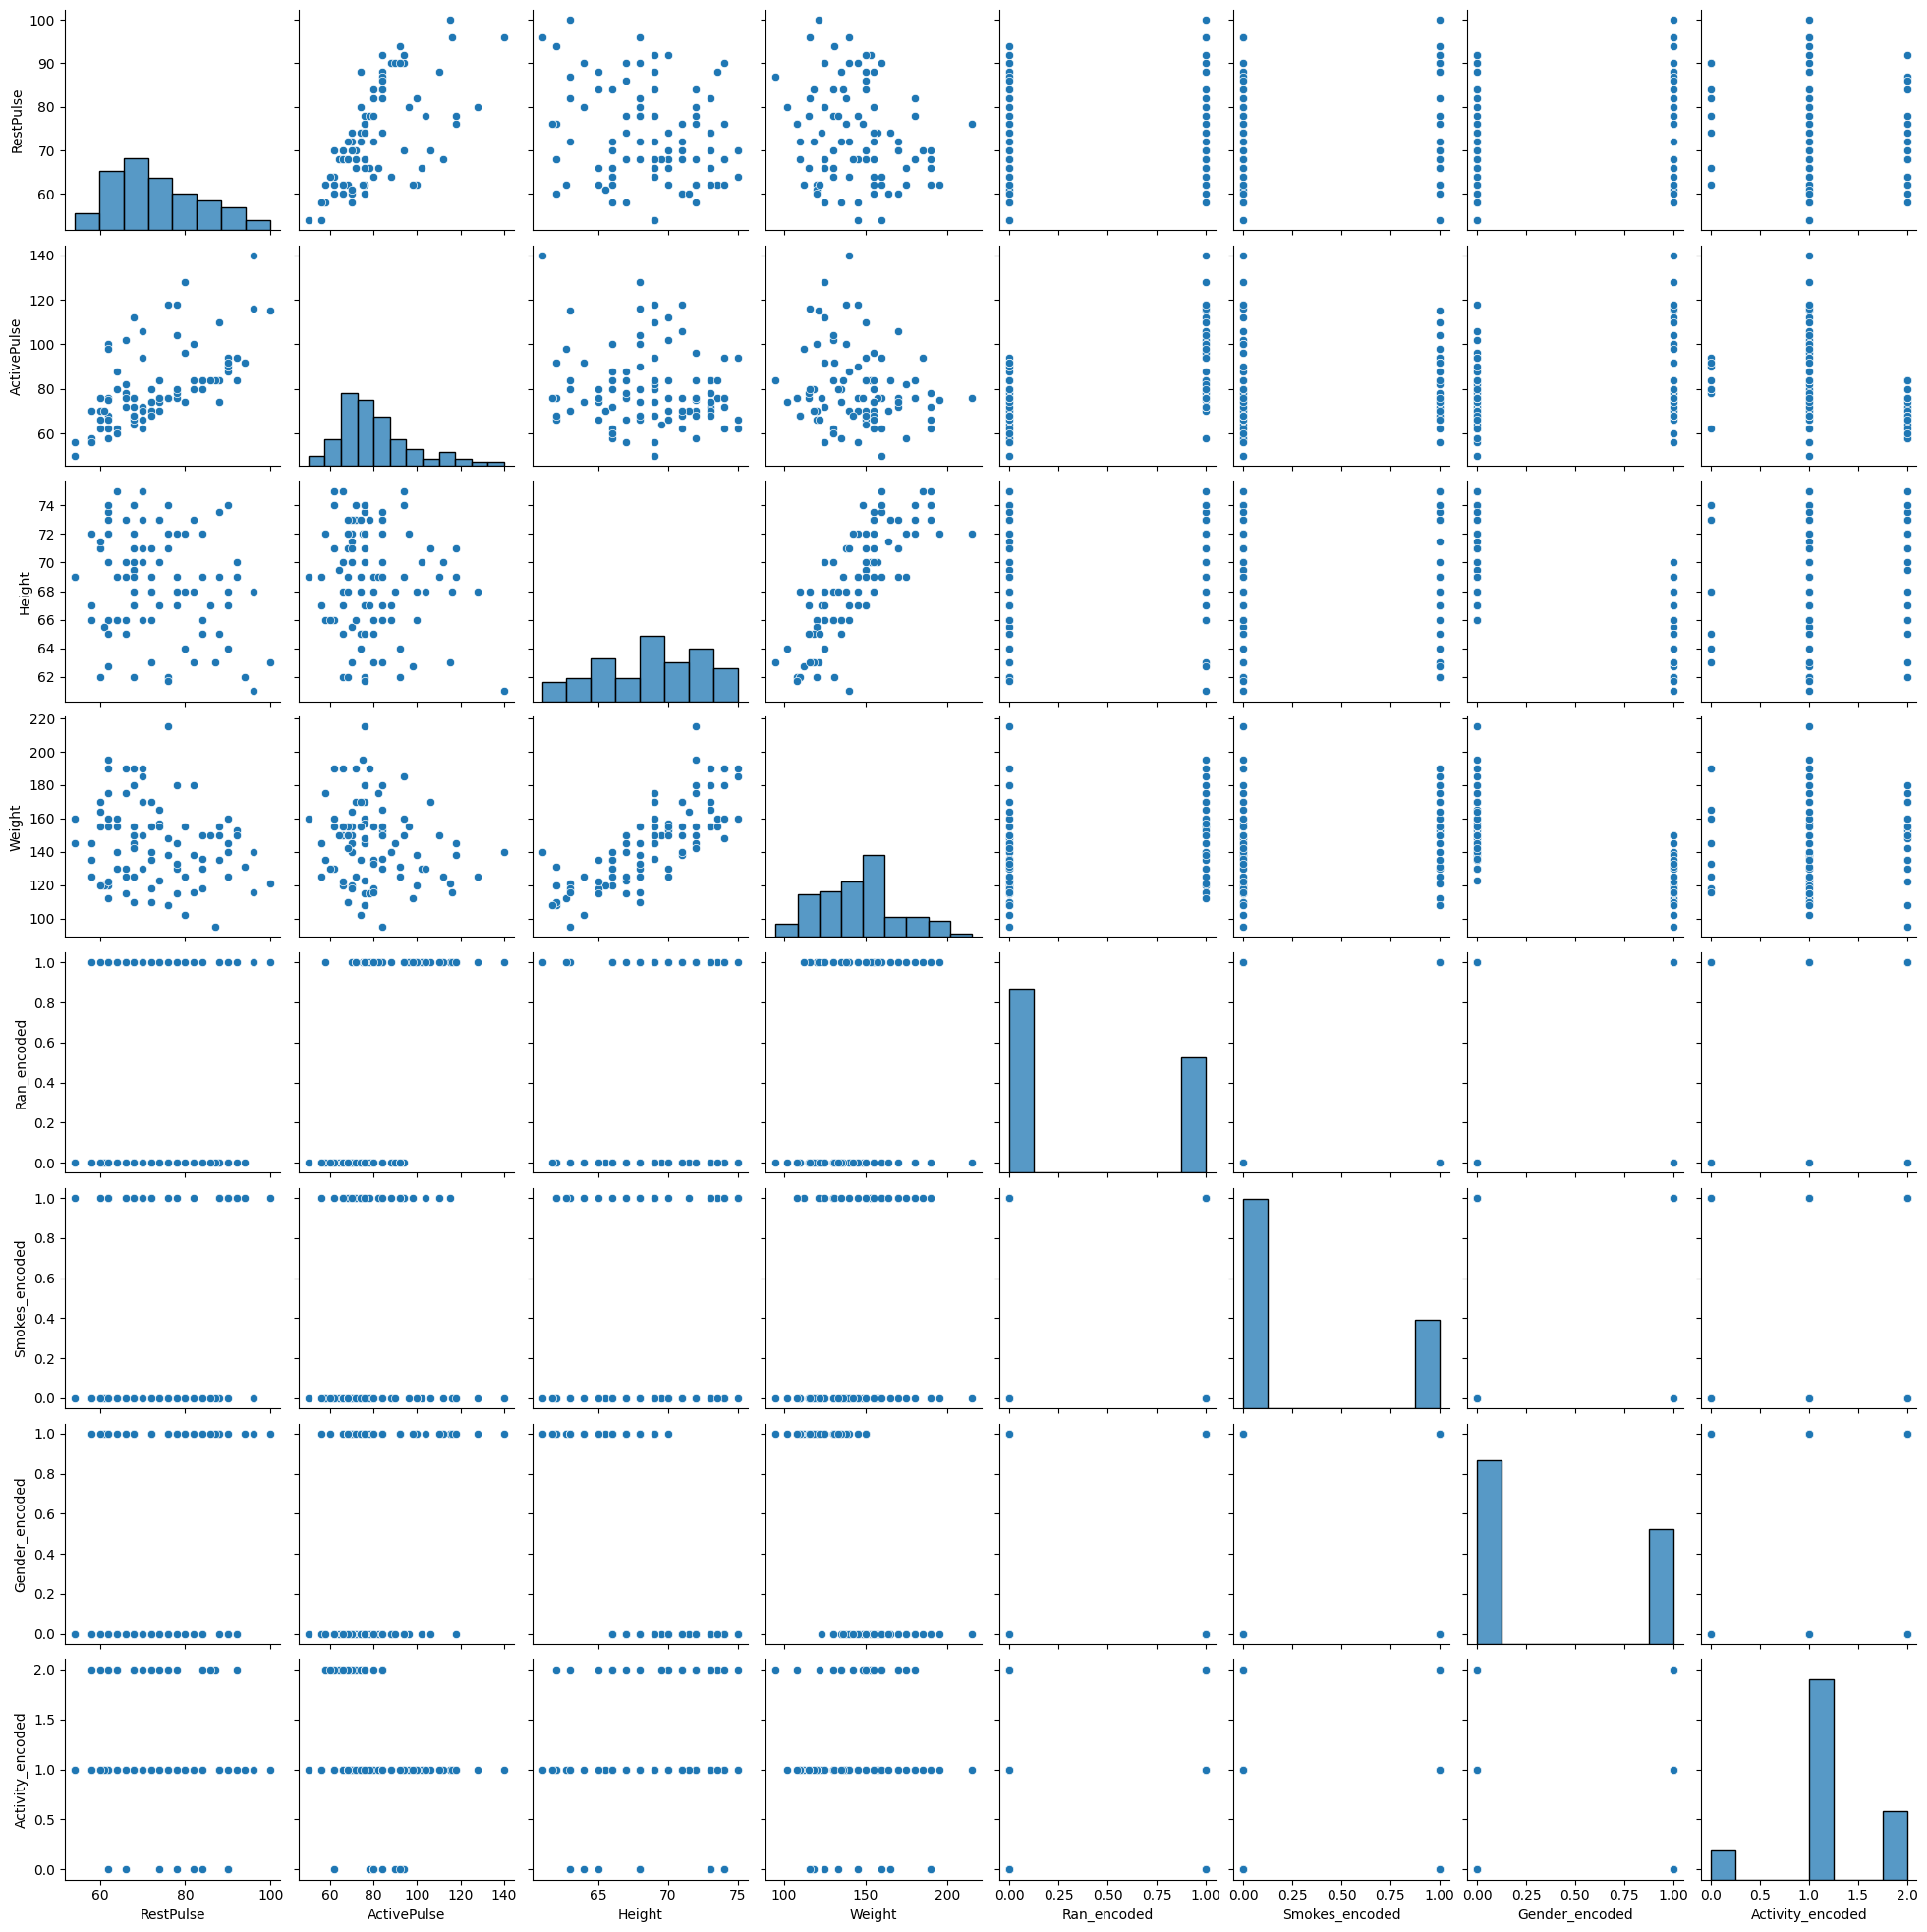

In [ ]:
sns.pairplot(temp_df)

 - Clear correlations between active and active pulse
 - Correlation between active pulse and if ran or not (go figures since if they didn't run their 'active' pulse would just be their resting pulse).
 - Relationship between height and weight.
 - Potentially inverse relationship between pulse (either one) and weight.
 - Height seems to have little impact on pulse.
 - Gender based differences: Pulse, Weight, & Height.
 - Based on the pairplot alone, whether someone is a smoker or not doesn't have a large effect.

##Likelyhood

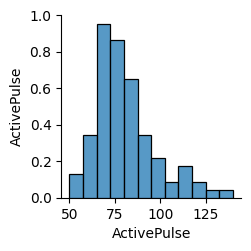

In [ ]:
sns.pairplot(temp_df, x_vars=['ActivePulse'], y_vars=['ActivePulse'])

 - Looks like either a Gamma or Skew Student T. So I'll try both as likelyhoods.

##Initial Causal Linear Model (Student T)

In [20]:
form = "RestPulse + Ran +  Height + Weight + Smokes + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Smokes + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}") #,f"sigma ~ {form}" I wanted variable variance but it was slowing the model down
model_init_stut = bmb.Model(formula, df, family = "t")
idata_init_stut = model_init_stut.fit(idata_kwargs={"log_likelihood":True})

Output()

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


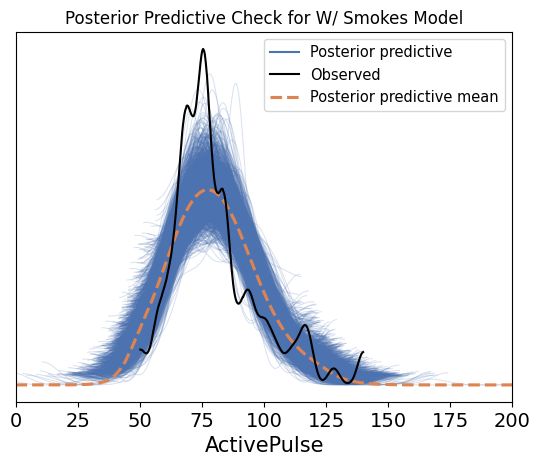

In [25]:
model_init_stut.predict(idata_init_stut, kind="pps")
axes = az.plot_ppc(idata_init_stut)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for W/ Smokes Model');

Maybe misaligned due to the data for pulse only being integers (makes it less continuous).

<Axes: xlabel='RestPulse', ylabel='ActivePulse'>

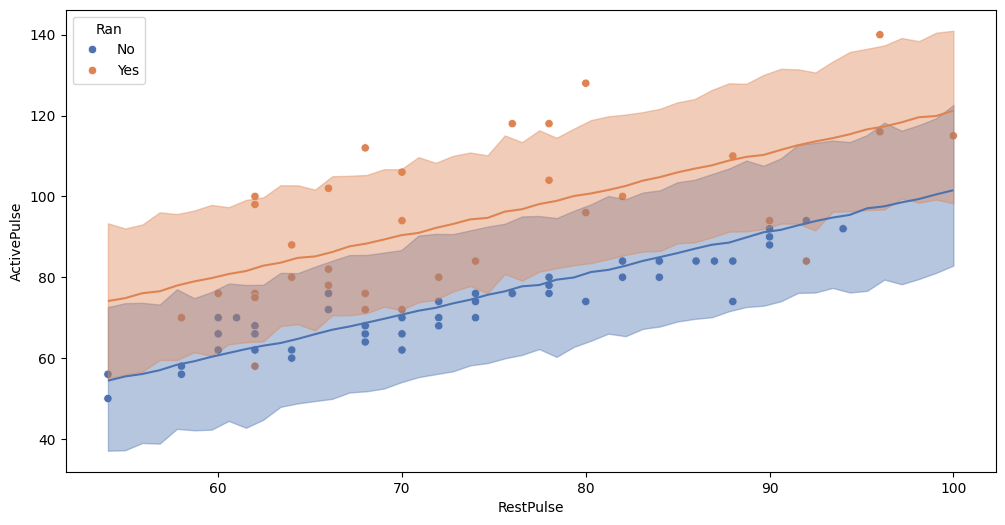

In [ ]:
unique_var = sorted(df.Ran.unique())
palette = sns.color_palette("deep", n_colors=len(unique_var))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
_, ax = plt.subplots(sharey=True, sharex="col", figsize=(12, 6))
bmb.interpret.plot_predictions(model_init_stut,idata_init_stut,["RestPulse","Ran"], ax=ax, pps=True)
sns.scatterplot(data=df,x="RestPulse",y="ActivePulse",hue="Ran",
                hue_order=unique_var,palette=palette,ax=ax,zorder=-3)


##Smoker Removal

* Trying since Smokes didn't seem to have much correlation in the data.

In [14]:
form = "RestPulse + Ran +  Height + Weight + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_nosm = bmb.Model(formula, df, family = "t")
idata_nosm = model_nosm.fit(idata_kwargs={"log_likelihood":True})

Output()

In [15]:
model_nosm.predict(idata_nosm, kind="pps")

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


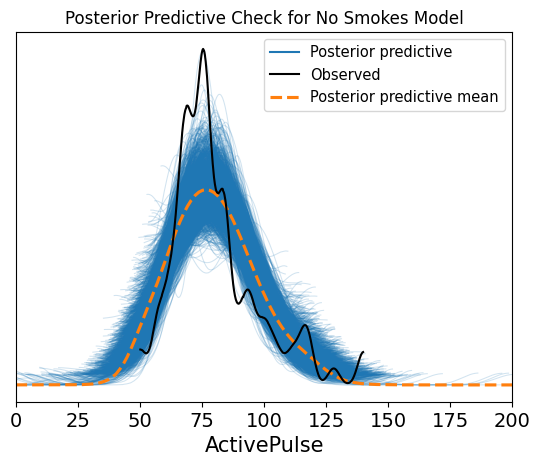

In [19]:
axes = az.plot_ppc(idata_nosm)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for No Smokes Model');

###Compare

In [ ]:
cmp = az.compare({
    'No Smokes':idata_nosm, "W/ Smokes":idata_init_stut
    })
cmp

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
W/ Smokes,0,-335.661763,18.156094,0.000000,0.890052,6.909150,0.000000,False,log
No Smokes,1,-337.715228,18.848812,2.053465,0.109948,7.988512,2.444788,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

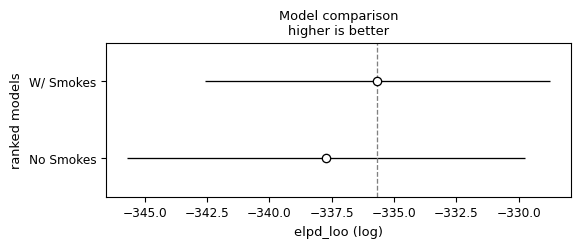

In [ ]:
az.plot_compare(cmp)



*   Marginal Loss.
*   Pretty much just as good.
*   Will remove going forward to improve preformance.



##Polynomial of Weight
* Pair plot between Weight and ActivePulse

In [ ]:
form = "RestPulse + Ran +  Height + poly(Weight, degree=2) + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_pwd2 = bmb.Model(formula, df, family = "t")
idata_pwd2 = model_pwd2.fit(idata_kwargs={"log_likelihood":True})

Output()

In [ ]:
form = "RestPulse + Ran +  Height + poly(Weight, degree=3) + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_pwd3 = bmb.Model(formula, df, family = "t")
idata_pwd3 = model_pwd3.fit(idata_kwargs={"log_likelihood":True})

Output()

In [ ]:
form = "RestPulse + Ran +  Height + poly(Weight, degree=4) + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_pwd4 = bmb.Model(formula, df, family = "t")
idata_pwd4 = model_pwd4.fit(idata_kwargs={"log_likelihood":True})

Output()

In [ ]:
cmp = az.compare({
    'deg 2':idata_pwd2,'deg 3':idata_pwd3,'deg 4':idata_pwd4, "No Poly":idata_nosm
    })
cmp

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
No Poly,0,-337.715228,18.848812,0.000000,1.000000e+00,7.988512,0.000000,True,log
deg 2,1,-338.452947,19.462431,0.737720,4.718448e-16,7.932295,0.591476,True,log
deg 3,2,-338.964519,19.611397,1.249291,0.000000e+00,7.832707,0.814641,False,log
deg 4,3,-340.599457,20.998635,2.884230,0.000000e+00,7.775510,1.311624,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

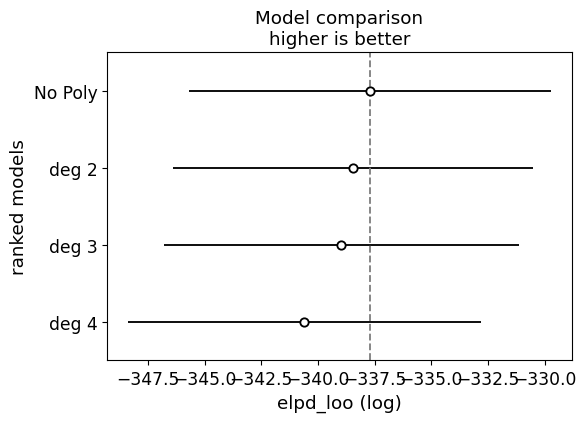

In [ ]:
az.plot_compare(cmp)



* The polynomial introduction is marginally worse than the original.
* Greater polynomial reduces performance.
* Not worth the computational cost for no gain.



####Graph of No Poly of Weight vs. Active Pulse

<Axes: xlabel='Weight', ylabel='ActivePulse'>

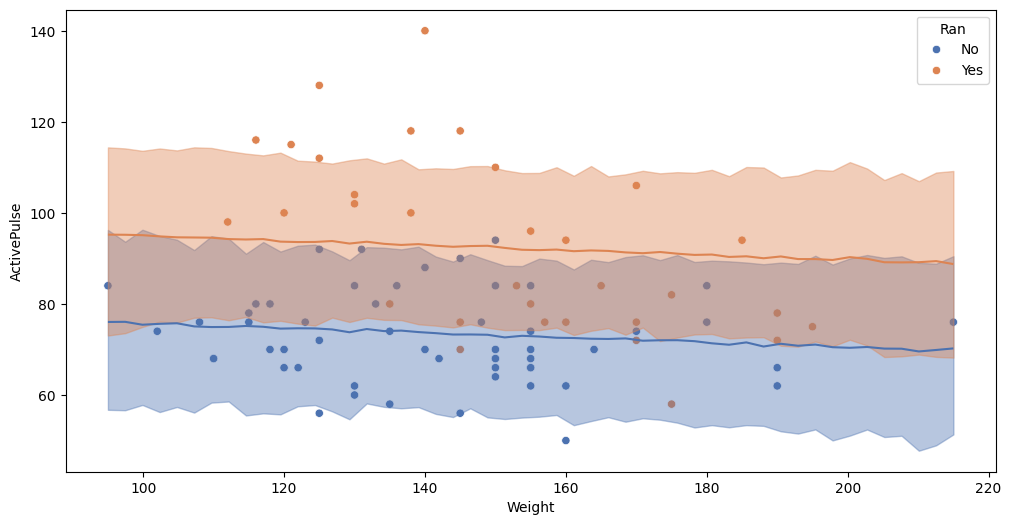

In [ ]:
unique_var = sorted(df.Ran.unique())
palette = sns.color_palette("deep", n_colors=len(unique_var))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
_, ax = plt.subplots(sharey=True, sharex="col", figsize=(12, 6))
bmb.interpret.plot_predictions(model_nosm,idata_nosm,["Weight","Ran"], ax=ax, pps=True)
sns.scatterplot(data=df,x="Weight",y="ActivePulse",hue="Ran",
                hue_order=unique_var,palette=palette,ax=ax,zorder=-3)

####Graph of Poly 2 of Weight vs. Active Pulse

<Axes: xlabel='Weight', ylabel='ActivePulse'>

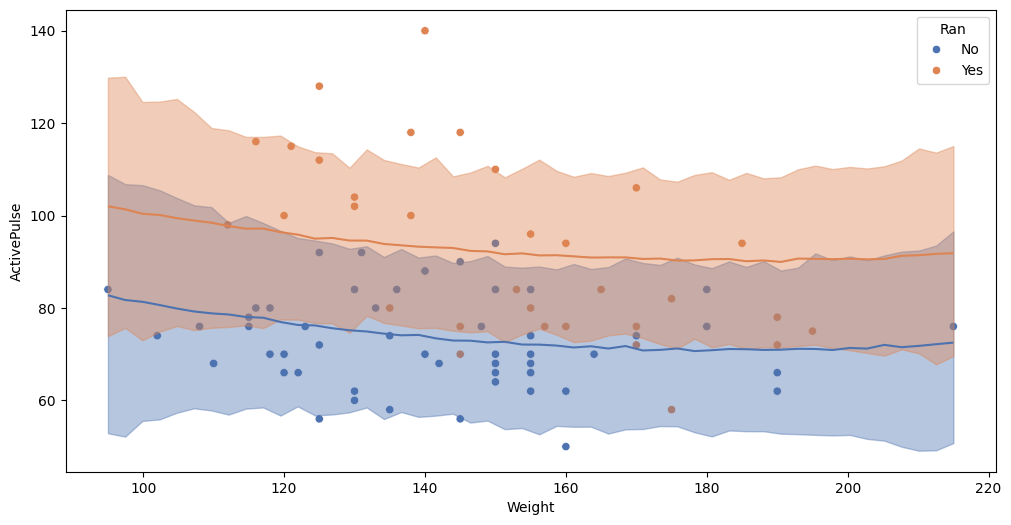

In [ ]:
unique_var = sorted(df.Ran.unique())
palette = sns.color_palette("deep", n_colors=len(unique_var))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
_, ax = plt.subplots(sharey=True, sharex="col", figsize=(12, 6))
bmb.interpret.plot_predictions(model_pwd2,idata_pwd2,["Weight","Ran"], ax=ax, pps=True)
sns.scatterplot(data=df,x="Weight",y="ActivePulse",hue="Ran",
                hue_order=unique_var,palette=palette,ax=ax,zorder=-3)

###Notes
Given the graphs, ran has some form of negative trend with weight that isn't being opperated on. So I want to see what happens if I make the entire model as a hierarchy.

In [22]:
form = "RestPulse + Height + Weight + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form} + (1|Ran) + ({form}|Ran)")
model_heir = bmb.Model(formula, df, family = "t")
idata_heir = model_heir.fit(idata_kwargs={"log_likelihood":True})

Output()

ERROR:pymc.stats.convergence:There were 112 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='RestPulse', ylabel='ActivePulse'>

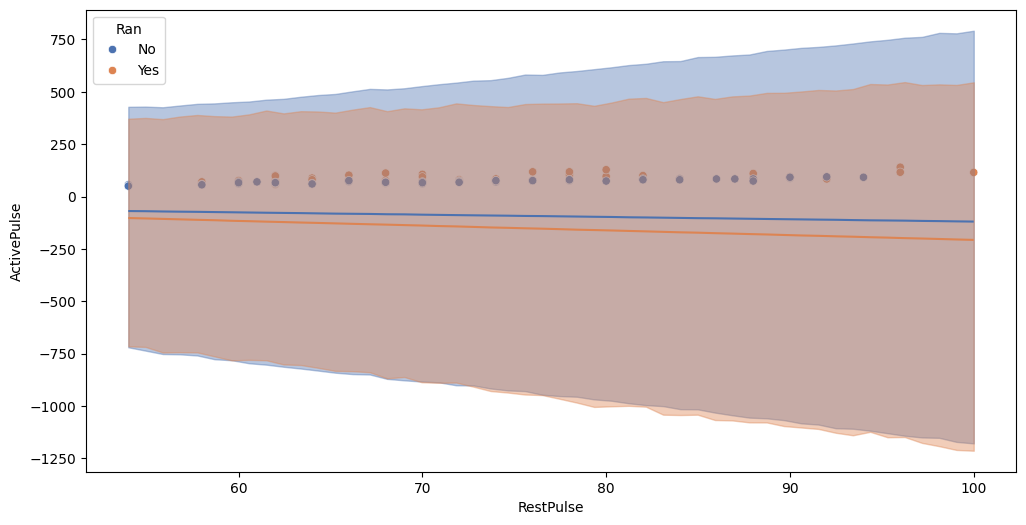

In [23]:
unique_var = sorted(df.Ran.unique())
palette = sns.color_palette("deep", n_colors=len(unique_var))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
_, ax = plt.subplots(sharey=True, sharex="col", figsize=(12, 6))
bmb.interpret.plot_predictions(model_heir,idata_heir,["RestPulse","Ran"], ax=ax, pps=True)
sns.scatterplot(data=df,x="RestPulse",y="ActivePulse",hue="Ran",
                hue_order=unique_var,palette=palette,ax=ax,zorder=-3)

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


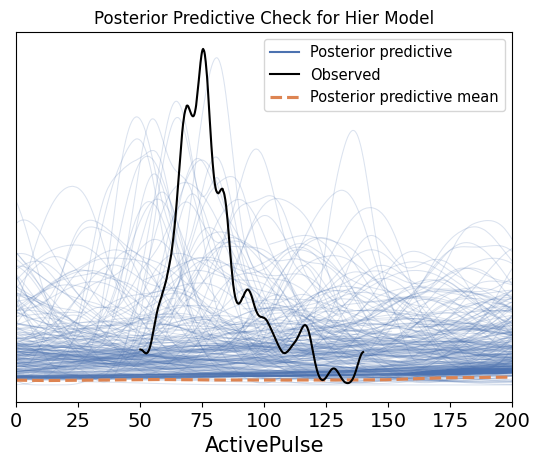

In [26]:
model_heir.predict(idata_heir, kind="pps")
axes = az.plot_ppc(idata_heir)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for Hier Model');

Runs super slow, took nearly 50 min.
Looks like it ran terribly,

In [24]:
cmp = az.compare({
    'Ran Hier':idata_heir, "Std":idata_nosm
    })
cmp

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Ran Hier,0,-319.608569,28.023822,0.000000,1.0,9.901215,0.000000,True,log
Std,1,-337.773758,18.937097,18.165189,0.0,7.939387,5.516881,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

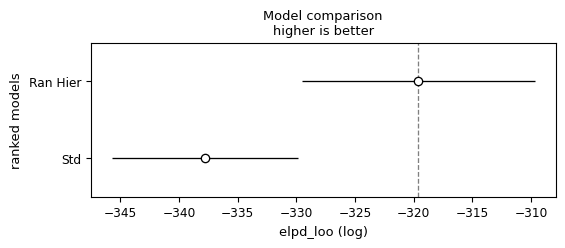

In [27]:
az.plot_compare(cmp)

For some reason I doubt this is actually better...

##Changing Model Variables & Interactions
Since most of these previous structural changes didn't go well. I want to move to testing my variables and the interactions between them.

In [ ]:
form = "RestPulse + Ran +  Height + Weight + Gender + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + RestPulse:Activity + Weight:Activity + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_ = bmb.Model(formula, df, family = "t")
idata_ = model_.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
model_.predict(idata_, kind="pps")
axes = az.plot_ppc(idata_)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for ___ Model');

In [ ]:
unique_var = sorted(df.Ran.unique())
palette = sns.color_palette("deep", n_colors=len(unique_var))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
_, ax = plt.subplots(sharey=True, sharex="col", figsize=(12, 6))
bmb.interpret.plot_predictions(model_,idata_,["RestPulse","Ran"], ax=ax, pps=True)
sns.scatterplot(data=df,x="RestPulse",y="ActivePulse",hue="Ran",
                hue_order=unique_var,palette=palette,ax=ax,zorder=-3)

###Non-Gender Variant
Test if my assumtions (and what appeared in the pair plot) about gender impacting bodily statistics holds up or not.

In [28]:
form = "RestPulse + Ran +  Height + Weight + Activity  + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Activity + Weight:Activity + Weight:Height"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_nog = bmb.Model(formula, df, family = "t")
idata_nog = model_nog.fit(idata_kwargs={"log_likelihood":True})

Output()

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


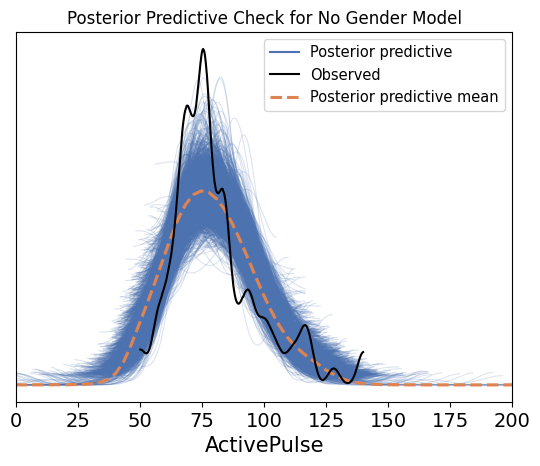

In [29]:
model_nog.predict(idata_nog, kind="pps")
axes = az.plot_ppc(idata_nog)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for No Gender Model');

###No Activity

In [31]:
form = "RestPulse + Ran +  Height + Weight + Gender + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + RestPulse:Gender + Weight:Gender + Weight:Height + Height:Gender"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_noac = bmb.Model(formula, df, family = "t")
idata_noac = model_noac.fit(idata_kwargs={"log_likelihood":True})

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


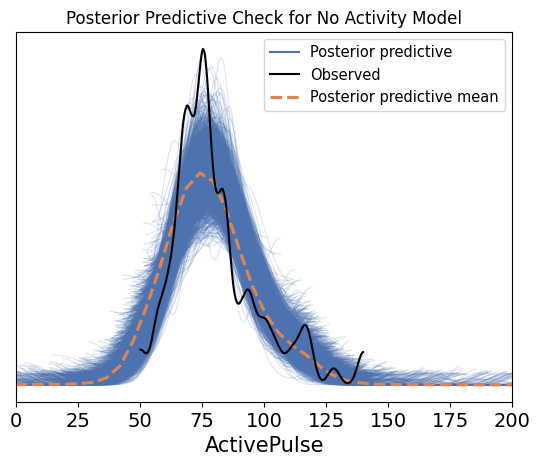

In [32]:
model_noac.predict(idata_noac, kind="pps")
axes = az.plot_ppc(idata_noac)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for No Activity Model');

###Just RP, Ran, Height, and Weight

In [33]:
form = "RestPulse + Ran +  Height + Weight + RestPulse:Height + RestPulse:Weight + RestPulse:Ran + Weight:Height"
formula = bmb.Formula(f"ActivePulse ~ {form}")
model_rprhw = bmb.Model(formula, df, family = "t")
idata_rprhw = model_rprhw.fit(idata_kwargs={"log_likelihood":True})

Output()

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


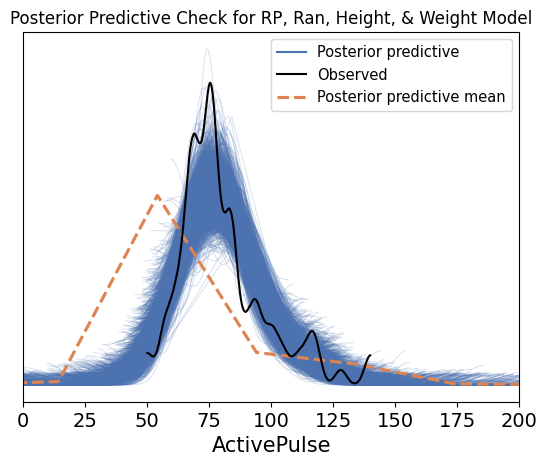

In [34]:
model_rprhw.predict(idata_rprhw, kind="pps")
axes = az.plot_ppc(idata_rprhw)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for RP, Ran, Height, & Weight Model');

###Only RP and Ran

In [36]:
model_rpr = bmb.Model("ActivePulse ~ RestPulse + Ran", df, family = "t")
idata_rpr = model_rpr.fit(idata_kwargs={"log_likelihood":True})

Output()

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


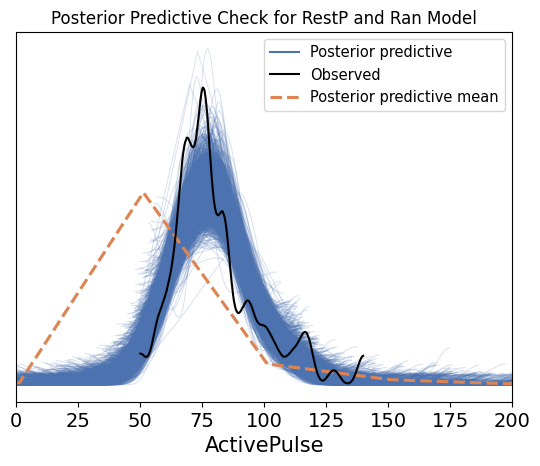

In [37]:
model_rpr.predict(idata_rpr, kind="pps")
axes = az.plot_ppc(idata_rpr)
axes.set_xlim(0, 200)
plt.title('Posterior Predictive Check for RestP and Ran Model');

###Compare

In [38]:
cmp = az.compare({
    'No Gen':idata_nog,'No Activ':idata_noac,'No Gen nor Activ':idata_rprhw,'Only RestP & Ran':idata_rpr, "Std":idata_nosm
    })
cmp

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Only RestP & Ran,0,-327.573023,6.201182,0.000000,7.027329e-01,12.579477,0.000000,False,log
No Gen nor Activ,1,-333.132147,15.205381,5.559124,2.323919e-13,11.103364,3.567525,False,log
No Gen,2,-336.886151,17.072034,9.313129,1.349435e-13,8.264972,7.412722,False,log
No Activ,3,-337.204856,20.565708,9.631833,2.636966e-13,10.432358,4.862330,False,log
Std,4,-337.773758,18.937097,10.200735,2.972671e-01,7.939387,8.155863,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

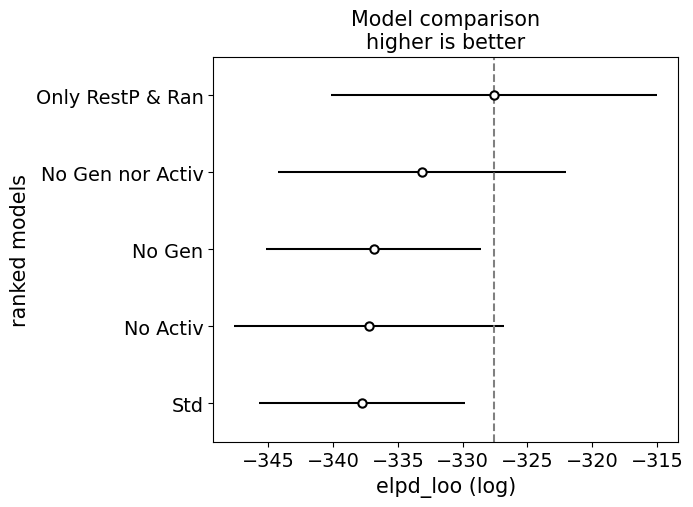

In [39]:
az.plot_compare(cmp)

I'm actually surprised that there was marginal improvement as I took out more and more items.

<Axes: xlabel='RestPulse', ylabel='ActivePulse'>

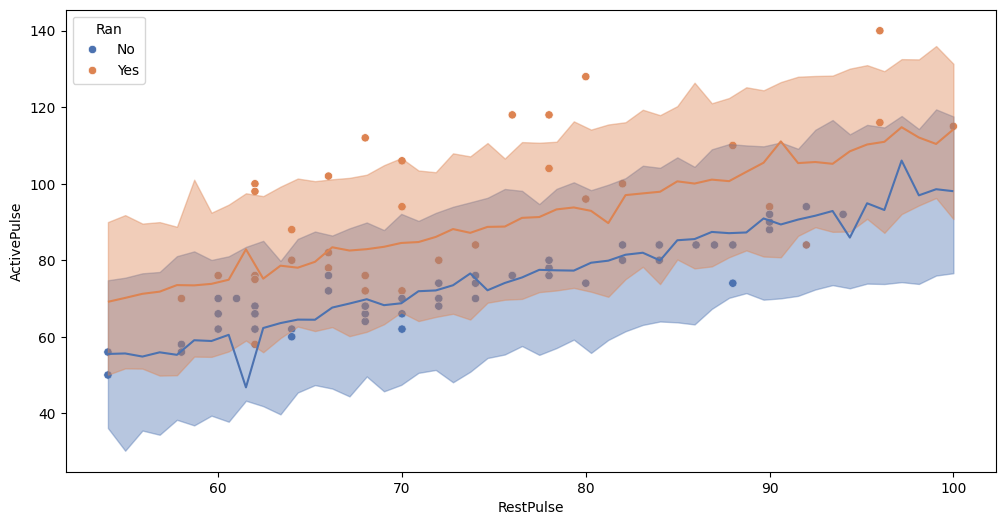

In [40]:
unique_var = sorted(df.Ran.unique())
palette = sns.color_palette("deep", n_colors=len(unique_var))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
_, ax = plt.subplots(sharey=True, sharex="col", figsize=(12, 6))
bmb.interpret.plot_predictions(model_rpr,idata_rpr,["RestPulse","Ran"], ax=ax, pps=True)
sns.scatterplot(data=df,x="RestPulse",y="ActivePulse",hue="Ran",
                hue_order=unique_var,palette=palette,ax=ax,zorder=-3)

####Updated Causal

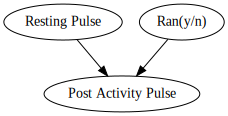

In [41]:

np_dag = gv.Digraph(name="New Pulse DAG")

np_dag.node('P','Resting Pulse')
np_dag.node('R','Ran(y/n)')
np_dag.node('p','Post Activity Pulse')

np_dag.edges(['Pp','Rp'])

np_dag


##Conclusion

Even though I thought that